In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [11]:
import numpy as np
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
import tensorflow as tf

print(tf.__version__)

# Nested block (skip connections with multiple convolutions)
def conv_block(x, filters, kernel_size=3, padding='same', activation='leaky_relu', kernel_initializer='he_normal'):
    conv = Conv2D(filters, kernel_size, padding=padding, kernel_initializer=kernel_initializer)(x)
    if activation == 'leaky_relu':
        conv = LeakyReLU()(conv)
    else:
        conv = Activation(activation)(conv)
    conv = Conv2D(filters, kernel_size, padding=padding, kernel_initializer=kernel_initializer)(conv)
    if activation == 'leaky_relu':
        conv = LeakyReLU()(conv)
    else:
        conv = Activation(activation)(conv)
    return conv

# UNet++ network
def unet_modify(pretrained_weights=None, input_size=(128, 128, 1)):
    size_filter_in = 16
    kernel_init = 'he_normal'
    activation_layer = None  # For convolution blocks
    
    inputs = Input(input_size)
    
    # Encoder path
    conv1_0 = conv_block(inputs, size_filter_in)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1_0)
    
    conv2_0 = conv_block(pool1, size_filter_in * 2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2_0)
    
    conv3_0 = conv_block(pool2, size_filter_in * 4)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3_0)
    
    conv4_0 = conv_block(pool3, size_filter_in * 8)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4_0)
    
    conv5_0 = conv_block(pool4, size_filter_in * 16)
    
    # Decoder path (with nested connections)
    conv4_1 = concatenate([conv4_0, UpSampling2D(size=(2, 2))(conv5_0)], axis=-1)
    conv4_1 = conv_block(conv4_1, size_filter_in * 8)
    
    conv3_2 = concatenate([conv3_0, UpSampling2D(size=(2, 2))(conv4_1)], axis=-1)
    conv3_2 = conv_block(conv3_2, size_filter_in * 4)
    
    conv2_3 = concatenate([conv2_0, UpSampling2D(size=(2, 2))(conv3_2)], axis=-1)
    conv2_3 = conv_block(conv2_3, size_filter_in * 2)
    
    conv1_4 = concatenate([conv1_0, UpSampling2D(size=(2, 2))(conv2_3)], axis=-1)
    conv1_4 = conv_block(conv1_4, size_filter_in)
    
    # Final convolutional layer
    conv_final = Conv2D(1, (1, 1), activation='tanh')(conv1_4)
    
    model = Model(inputs, conv_final)
    
    model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
    
    if pretrained_weights:
        model.load_weights(pretrained_weights)
    
    return model


2.18.0


In [9]:
import numpy as np

X_in = np.load('/kaggle/input/new-vocal-removal/Speech-enhancementmusic_voice_amp_db.npy')
X_ou = np.load('/kaggle/input/new-vocal-removal/Speech-enhancementvoice_amp_db.npy')

# n_samples = int(X_in.shape[0] * 1)

# X_in = X_in[n_samples:]
# X_ou = X_ou[n_samples:]

# X_ou = X_in - X_ou

In [10]:
from scipy import stats

print("Input:", stats.describe(X_in.reshape(-1,1)))
print("Output:", stats.describe(X_ou.reshape(-1,1)))

Input: DescribeResult(nobs=327680000, minmax=(array([-80.]), array([0.])), mean=array([-39.30280432]), variance=array([230.48530196]), skewness=array([-0.38891374]), kurtosis=array([0.27714779]))
Output: DescribeResult(nobs=327680000, minmax=(array([-80.]), array([0.])), mean=array([-34.9720143]), variance=array([503.28964805]), skewness=array([0.09007292]), kurtosis=array([-0.77306003]))


In [12]:
X_in = (X_in + 40)/40  # Điều chỉnh để đưa khoảng [-80, 0] về [-1, 1]

# X_ou có min=-80, max=80
# X_ou = X_ou/80  # Điều chỉnh để đưa khoảng [-80, 80] về [-1, 1]
X_ou = (X_ou + 40)/40

In [13]:
print(X_in.shape,X_ou.shape)


(20000, 128, 128) (20000, 128, 128)


In [8]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

#Reshape for training
X_in = X_in[:,:,:]
X_in = X_in.reshape(X_in.shape[0],X_in.shape[1],X_in.shape[2],1)
X_ou = X_ou[:,:,:]
X_ou = X_ou.reshape(X_ou.shape[0],X_ou.shape[1],X_ou.shape[2],1)

X_train, X_test, y_train, y_test = train_test_split(X_in, X_ou, test_size=0.2, random_state=42)

#If training from pre-trained weights
generator_nn = unet_modify(input_size=(128, 128, 1))  
#generator_nn=unet_modify(pretrained_weights = '/kaggle/working/model-037-0.007457.keras')

#If training from scratch
#generator_nn=unet()
#Save best models to disk
checkpoint = ModelCheckpoint('/kaggle/working/model-{epoch:03d}-{val_loss:06f}.keras', 
                             verbose=1, monitor='val_loss', save_best_only=True, mode='auto')
generator_nn.summary()
#Training



history = generator_nn.fit(X_train, y_train, epochs=100, batch_size=80, shuffle=True, callbacks=[checkpoint], verbose=1, validation_data=(X_test, y_test))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 128, 128, 16)   │            160 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_18            │ (None, 128, 128, 16)   │              0 │ conv2d_19[0][0]        │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 128, 128, 16)   │          2,320 │ leaky_re_lu_18[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_19            │ (None, 128, 128, 16)   │              0 │ conv2d_20[0][0]        │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 64, 64, 16)     │              0 │ leaky_re_lu_19[0][0]   │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 64, 64, 32)     │          4,640 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_20            │ (None, 64, 64, 32)     │              0 │ conv2d_21[0][0]        │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 64, 64, 32)     │          9,248 │ leaky_re_lu_20[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_21            │ (None, 64, 64, 32)     │              0 │ conv2d_22[0][0]        │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 32, 32, 32)     │              0 │ leaky_re_lu_21[0][0]   │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 32, 32, 64)     │         18,496 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_22            │ (None, 32, 32, 64)     │              0 │ conv2d_23[0][0]        │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ leaky_re_lu_22[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_23            │ (None, 32, 32, 64)     │              0 │ conv2d_24[0][0]        │
│ (LeakyReLU)               │                        │                │                        │
├──────────────────────

 Total params: 1,962,337 (7.49 MB)

 Trainable params: 1,962,337 (7.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


NameError: name 'CHUNK_SIZE' is not defined

In [14]:
import numpy as np
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau, CSVLogger
import tensorflow as tf
import tensorflow.keras.backend as K

print(tf.__version__)

# Custom loss function for spectral data
def spectral_loss(y_true, y_pred):
    """
    Custom spectral loss combining MAE and MSE for better audio quality
    Suitable for amplitude spectrogram data
    """
    # Mean Absolute Error for preserving spectral shape
    mae_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
       
    # Weighted combination (emphasize MAE for spectral preservation)
    return mae_loss

# Custom SDR metric for audio separation quality
def sdr(y_true, y_pred):
    """
    Signal-to-Distortion Ratio metric adapted for spectrogram data
    Higher values indicate better separation quality
    """
    # Add small epsilon to avoid division by zero
    epsilon = 1e-8
    
    # Calculate signal power (numerator)
    signal_power = tf.reduce_sum(tf.square(y_true), axis=[1, 2, 3]) + epsilon
    
    # Calculate distortion power (denominator)
    distortion_power = tf.reduce_sum(tf.square(y_true - y_pred), axis=[1, 2, 3]) + epsilon
    
    # SDR in dB scale
    sdr_db = 10.0 * tf.math.log(signal_power / distortion_power) / tf.math.log(10.0)
    
    return tf.reduce_mean(sdr_db)

# Nested block (skip connections with multiple convolutions)
def conv_block(x, filters, kernel_size=3, padding='same', activation='leaky_relu', kernel_initializer='he_normal'):
    conv = Conv2D(filters, kernel_size, padding=padding, kernel_initializer=kernel_initializer)(x)
    if activation == 'leaky_relu':
        conv = LeakyReLU()(conv)
    else:
        conv = Activation(activation)(conv)
    conv = Conv2D(filters, kernel_size, padding=padding, kernel_initializer=kernel_initializer)(conv)
    if activation == 'leaky_relu':
        conv = LeakyReLU()(conv)
    else:
        conv = Activation(activation)(conv)
    return conv

# UNet++ network
def unet_modify(pretrained_weights=None, input_size=(128, 128, 1)):
    size_filter_in = 16
    kernel_init = 'he_normal'
    activation_layer = None  # For convolution blocks
    
    inputs = Input(input_size)
    
    # Encoder path
    conv1_0 = conv_block(inputs, size_filter_in)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1_0)
    
    conv2_0 = conv_block(pool1, size_filter_in * 2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2_0)
    
    conv3_0 = conv_block(pool2, size_filter_in * 4)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3_0)
    
    conv4_0 = conv_block(pool3, size_filter_in * 8)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4_0)
    
    conv5_0 = conv_block(pool4, size_filter_in * 16)
    
    # Decoder path (with nested connections)
    conv4_1 = concatenate([conv4_0, UpSampling2D(size=(2, 2))(conv5_0)], axis=-1)
    conv4_1 = conv_block(conv4_1, size_filter_in * 8)
    
    conv3_2 = concatenate([conv3_0, UpSampling2D(size=(2, 2))(conv4_1)], axis=-1)
    conv3_2 = conv_block(conv3_2, size_filter_in * 4)
    
    conv2_3 = concatenate([conv2_0, UpSampling2D(size=(2, 2))(conv3_2)], axis=-1)
    conv2_3 = conv_block(conv2_3, size_filter_in * 2)
    
    conv1_4 = concatenate([conv1_0, UpSampling2D(size=(2, 2))(conv2_3)], axis=-1)
    conv1_4 = conv_block(conv1_4, size_filter_in)
    
    # Final convolutional layer
    conv_final = Conv2D(1, (1, 1), activation='tanh')(conv1_4)
    
    model = Model(inputs, conv_final)
    
    # Updated compilation with custom loss and metrics
    optimizer = Adam(learning_rate=5e-05)
    model.compile(
        optimizer=optimizer, 
        loss=spectral_loss, 
        metrics=[sdr]
    )
    
    if pretrained_weights:
        model.load_weights(pretrained_weights)
    
    return model

# Load and preprocess data
X_in = np.load('/kaggle/input/new-vocal-removal/Speech-enhancementmusic_voice_amp_db.npy')
X_ou = np.load('/kaggle/input/new-vocal-removal/Speech-enhancementvoice_amp_db.npy')

# X_ou = X_in - X_ou

X_in = (X_in + 40)/40  # Điều chỉnh để đưa khoảng [-80, 0] về [-1, 1]
X_ou = (X_ou + 40)/40 

from sklearn.model_selection import train_test_split

#Reshape for training
X_in = X_in[:,:,:]
X_in = X_in.reshape(X_in.shape[0],X_in.shape[1],X_in.shape[2],1)
X_ou = X_ou[:,:,:]
X_ou = X_ou.reshape(X_ou.shape[0],X_ou.shape[1],X_ou.shape[2],1)
X_train, X_test, y_train, y_test = train_test_split(X_in, X_ou, test_size=0.2, random_state=42)

# Initialize model
generator_nn = unet_modify(input_size=(128, 128, 1))

# Setup callbacks
checkpoint = ModelCheckpoint('/kaggle/working/model-{epoch:03d}-{val_sdr:.6f}.keras', 
                             verbose=1, monitor='val_sdr', save_best_only=True, mode='max')

reduce_lr = ReduceLROnPlateau(
    monitor='val_sdr',
    factor=0.95, 
    patience=2,
    mode='max',
    verbose=1
)

CSV_LOG_PATH = '/kaggle/working/training_log.csv'
csv_logger = CSVLogger(CSV_LOG_PATH)

generator_nn.summary()

# Training
history = generator_nn.fit(
    X_train, y_train, 
    epochs=30, 
    shuffle=False, 
    callbacks=[checkpoint, reduce_lr, csv_logger], 
    verbose=1, 
    validation_data=(X_test, y_test)
)

2.18.0


I0000 00:00:1749826633.884255      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749826633.885048      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 16)   │            160 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 128, 128, 16)   │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 16)   │          2,320 │ leaky_re_lu[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 128, 128, 16)   │              0 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 16)     │              0 │ leaky_re_lu_1[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 32)     │          4,640 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 64, 64, 32)     │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 32)     │          9,248 │ leaky_re_lu_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU) │ (None, 64, 64, 32)     │              0 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 32)     │              0 │ leaky_re_lu_3[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 64)     │         18,496 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU) │ (None, 32, 32, 64)     │              0 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ leaky_re_lu_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU) │ (None, 32, 32, 64)     │              0 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 64)     │              0 │ leaky_re_lu_5[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 128)    │         73,856 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU) │ (None, 16, 16, 128)    │              0 │ conv2d_6[0][0]         │
├──────────────────────

 Total params: 1,962,337 (7.49 MB)

...

Epoch 1/30


I0000 00:00:1749826651.933617     119 service.cc:148] XLA service 0x7d8710025e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749826651.940934     119 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749826651.940958     119 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749826653.124749     119 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/500 ━━━━━━━━━━━━━━━━━━━━ 2:54:14 21s/step - loss: 0.8404 - sdr: -4.9825

I0000 00:00:1749826664.337497     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.4221 - sdr: 1.0424
Epoch 1: val_sdr improved from -inf to 2.02372, saving model to /kaggle/working/model-001-2.023715.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - loss: 0.4221 - sdr: 1.0434 - val_loss: 0.3874 - val_sdr: 2.0237 - learning_rate: 5.0000e-05
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3857 - sdr: 1.9838
Epoch 2: val_sdr improved from 2.02372 to 2.28206, saving model to /kaggle/working/model-002-2.282061.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - loss: 0.3857 - sdr: 1.9839 - val_loss: 0.3766 - val_sdr: 2.2821 - learning_rate: 5.0000e-05
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.3745 - sdr: 2.2380
Epoch 3: val_sdr improved from 2.28206 to 2.49122, saving model to /kaggle/working/model-003-2.491215.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - loss: 0.3745 - sdr: 2.2382 - val_loss: 0.3685 - val_sdr: 2.4912 - learning_rate: 5.0000e-05
Epoch 4/30
500/500 ━━━━━━━━━━━━━━

In [22]:
X_pred_test = generator_nn.predict(X_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


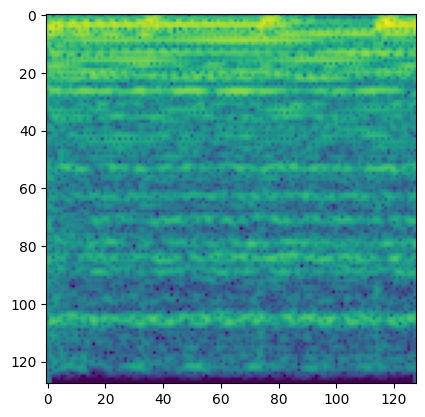

In [39]:
import matplotlib.pyplot as plt
%matplotlib inline
id = 40
plt.imshow(X_test[id,:,:,0])

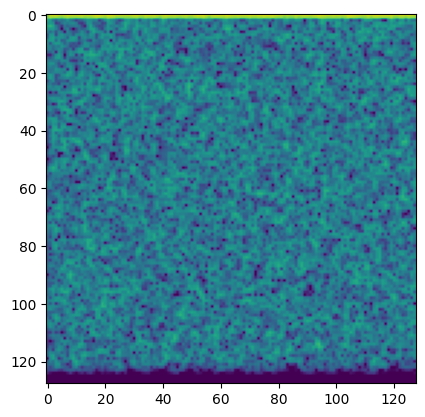

In [40]:
plt.imshow(y_test[id,:,:,0])


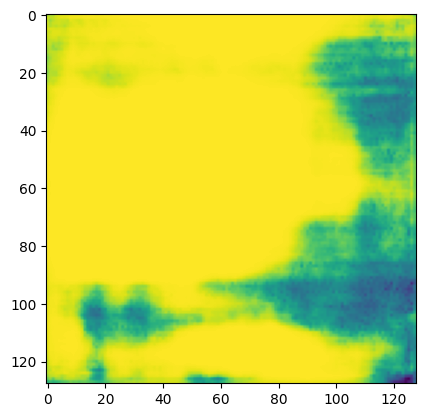

In [41]:
plt.imshow(X_pred_test[id,:,:,0])


**Inferrence**

In [3]:
import librosa
import numpy as np
import os


def audio_to_audio_frame_stack(sound_data, frame_length, hop_length_frame):
    """This function take an audio and split into several frame
       in a numpy matrix of size (nb_frame,frame_length)"""

    sequence_sample_length = sound_data.shape[0]

    sound_data_list = [sound_data[start:start + frame_length] for start in range(
    0, sequence_sample_length - frame_length + 1, hop_length_frame)]  # get sliding windows
    sound_data_array = np.vstack(sound_data_list)

    return sound_data_array


def audio_files_to_numpy(audio_dir, list_audio_files, sample_rate, frame_length, hop_length_frame, min_duration):
    """This function take audio files of a directory and merge them
    in a numpy matrix of size (nb_frame,frame_length) for a sliding window of size hop_length_frame"""

    list_sound_array = []

    for file in list_audio_files:
        # open the audio file
        y, sr = librosa.load(os.path.join(audio_dir, file), sr=sample_rate)
        total_duration = librosa.get_duration(y=y, sr=sr)

        if (total_duration >= min_duration):
            list_sound_array.append(audio_to_audio_frame_stack(
                y, frame_length, hop_length_frame))
        else:
            print(
                f"The following file {os.path.join(audio_dir,file)} is below the min duration")

    return np.vstack(list_sound_array)


def blend_noise_randomly(voice, noise, nb_samples, frame_length):
    """This function takes as input numpy arrays representing frames
    of voice sounds, noise sounds and the number of frames to be created
    and return numpy arrays with voice randomly blend with noise"""

    prod_voice = np.zeros((nb_samples, frame_length))
    prod_noise = np.zeros((nb_samples, frame_length))
    prod_noisy_voice = np.zeros((nb_samples, frame_length))

    for i in range(nb_samples):
        id_voice = np.random.randint(0, voice.shape[0])
        id_noise = np.random.randint(0, noise.shape[0])
        level_noise = np.random.uniform(0.2, 0.8)
        prod_voice[i, :] = voice[id_voice, :]
        prod_noise[i, :] = level_noise * noise[id_noise, :]
        prod_noisy_voice[i, :] = prod_voice[i, :] + prod_noise[i, :]

    return prod_voice, prod_noise, prod_noisy_voice


def audio_to_magnitude_db_and_phase(n_fft, hop_length_fft, audio):
    """This function takes an audio and convert into spectrogram,
       it returns the magnitude in dB and the phase"""

    stftaudio = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length_fft)
    stftaudio_magnitude, stftaudio_phase = librosa.magphase(stftaudio)

    stftaudio_magnitude_db = librosa.amplitude_to_db(
        stftaudio_magnitude, ref=np.max)

    return stftaudio_magnitude_db, stftaudio_phase


def numpy_audio_to_matrix_spectrogram(numpy_audio, dim_square_spec, n_fft, hop_length_fft):
    """This function takes as input a numpy audi of size (nb_frame,frame_length), and return
    a numpy containing the matrix spectrogram for amplitude in dB and phase. It will have the size
    (nb_frame,dim_square_spec,dim_square_spec)"""

    nb_audio = numpy_audio.shape[0]

    m_mag_db = np.zeros((nb_audio, dim_square_spec, dim_square_spec))
    m_phase = np.zeros((nb_audio, dim_square_spec, dim_square_spec), dtype=complex)

    for i in range(nb_audio):
        m_mag_db[i, :, :], m_phase[i, :, :] = audio_to_magnitude_db_and_phase(
            n_fft, hop_length_fft, numpy_audio[i])

    return m_mag_db, m_phase


def magnitude_db_and_phase_to_audio(frame_length, hop_length_fft, stftaudio_magnitude_db, stftaudio_phase):
    """This functions reverts a spectrogram to an audio"""

    stftaudio_magnitude_rev = librosa.db_to_amplitude(stftaudio_magnitude_db, ref=1.0)

    # taking magnitude and phase of audio
    audio_reverse_stft = stftaudio_magnitude_rev * stftaudio_phase
    audio_reconstruct = librosa.core.istft(audio_reverse_stft, hop_length=hop_length_fft, length=frame_length)

    return audio_reconstruct

def matrix_spectrogram_to_numpy_audio(m_mag_db, m_phase, frame_length, hop_length_fft)  :
    """This functions reverts the matrix spectrograms to numpy audio"""

    list_audio = []

    nb_spec = m_mag_db.shape[0]

    for i in range(nb_spec):

        audio_reconstruct = magnitude_db_and_phase_to_audio(frame_length, hop_length_fft, m_mag_db[i], m_phase[i])
        list_audio.append(audio_reconstruct)

    return np.vstack(list_audio)

def scaled_in(matrix_spec):
    "global scaling apply to noisy voice spectrograms (scale between -1 and 1)"
    matrix_spec = (matrix_spec + 40)/40
    return matrix_spec
# X_in = (X_in + 40)/40  # Điều chỉnh để đưa khoảng [-80, 0] về [-1, 1]
# X_ou = (X_ou + 40)/40 
def scaled_ou(matrix_spec):
    "global scaling apply to noise models spectrograms (scale between -1 and 1)"
    matrix_spec = (matrix_spec + 40 )/40
    return matrix_spec

def inv_scaled_in(matrix_spec):
    "inverse global scaling apply to noisy voices spectrograms"
    matrix_spec = matrix_spec * 40 - 40
    return matrix_spec

def inv_scaled_ou(matrix_spec):
    "inverse global scaling apply to noise models spectrograms"
    matrix_spec = matrix_spec * 40 - 40
    return matrix_spec

In [10]:
import os,sys,inspect
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
sys.path.append('..')
import librosa
import tensorflow as tf
import soundfile as sf

def spectral_loss(y_true, y_pred):
    """
    Custom spectral loss combining MAE and MSE for better audio quality
    Suitable for amplitude spectrogram data
    """
    # Mean Absolute Error for preserving spectral shape
    mae_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
       
    # Weighted combination (emphasize MAE for spectral preservation)
    return mae_loss

# Custom SDR metric for audio separation quality
def sdr(y_true, y_pred):
    """
    Signal-to-Distortion Ratio metric adapted for spectrogram data
    Higher values indicate better separation quality
    """
    # Add small epsilon to avoid division by zero
    epsilon = 1e-8
    
    # Calculate signal power (numerator)
    signal_power = tf.reduce_sum(tf.square(y_true), axis=[1, 2, 3]) + epsilon
    
    # Calculate distortion power (denominator)
    distortion_power = tf.reduce_sum(tf.square(y_true - y_pred), axis=[1, 2, 3]) + epsilon
    
    # SDR in dB scale
    sdr_db = 10.0 * tf.math.log(signal_power / distortion_power) / tf.math.log(10.0)
    
    return tf.reduce_mean(sdr_db)


custom_objects = {
    'spectral_loss': spectral_loss,
    'sdr': sdr
}

loaded_model = tf.keras.models.load_model('/kaggle/input/unet-model-normal/model-011-3.111443.keras', 
                         custom_objects=custom_objects)
audio_dir_prediction = '/kaggle/working'

audio_input_prediction = ['/kaggle/input/test-unet-removal-voices/muahong-lequyen.wav']

# Sample rate chosen to read audio
sample_rate = 8000

# Minimum duration of audio files to consider
min_duration = 1.0

# Our training data will be frame of slightly above 1 second
frame_length = 8064

# hop length for clean voice files separation (no overlap)
hop_length_frame = 8064

# hop length for noise files (we split noise into several windows)
hop_length_frame_noise = 5000


# Extracting noise and voice from folder and convert to numpy
audio = audio_files_to_numpy(audio_dir_prediction, audio_input_prediction, sample_rate,
                             frame_length, hop_length_frame, min_duration)

# Choosing n_fft and hop_length_fft to have squared spectrograms
n_fft = 255
hop_length_fft = 63

dim_square_spec = int(n_fft / 2) + 1

# Create Amplitude and phase of the sounds
m_amp_db_audio,  m_pha_audio = numpy_audio_to_matrix_spectrogram(
    audio, dim_square_spec, n_fft, hop_length_fft)

#global scaling to have distribution -1/1
X_in = scaled_in(m_amp_db_audio)
print(f"Amplitude before denoising: {np.max(X_in)}")

#Reshape for prediction
X_in = X_in.reshape(X_in.shape[0],X_in.shape[1],X_in.shape[2],1)
#Prediction using loaded network
X_pred = loaded_model.predict(X_in)
#Rescale back the noise model
inv_sca_X_pred = inv_scaled_ou(X_pred)
#Remove noise model from noisy speech
X_denoise = inv_sca_X_pred[:,:,:,0]
#Reconstruct audio from denoised spectrogram and phase
audio_denoise_recons = matrix_spectrogram_to_numpy_audio(X_denoise, m_pha_audio, frame_length, hop_length_fft)
#Number of frames
nb_samples = audio_denoise_recons.shape[0]
audio_denoise_recons *= 6.0

output_wav_path = '/kaggle/working/removal_audio.mp3'
sf.write(output_wav_path, audio_denoise_recons.flatten(), sample_rate)
print(f"Audio saved to {output_wav_path}")
print(f"Amplitude after denoising: {np.max(X_denoise)}")
def test_dimensions_spectrogram():
    """ test that dimensions are correct"""
    assert dim_square_spec == 128
    assert dim_square_spec == m_amp_db_audio.shape[1]
    assert dim_square_spec == m_amp_db_audio.shape[2]
    assert dim_square_spec == X_denoise.shape[1]
    assert dim_square_spec == X_denoise.shape[2]
    assert nb_samples == 5

Amplitude before denoising: 1.0000000953674317
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step
Audio saved to /kaggle/working/removal_audio.mp3
Amplitude after denoising: -2.288818359375e-05


In [21]:
X_in = np.load('/kaggle/input/new-vocal-removal/Speech-enhancementmusic_voice_amp_db.npy')
X_ou = np.load('/kaggle/input/new-vocal-removal/Speech-enhancementvoice_amp_db.npy')

# X_ou = X_in - X_ou

X_in = (X_in + 40)/40  # Điều chỉnh để đưa khoảng [-80, 0] về [-1, 1]
X_ou = (X_ou + 40)/40 

from sklearn.model_selection import train_test_split

#Reshape for training
X_in = X_in[:,:,:]
X_in = X_in.reshape(X_in.shape[0],X_in.shape[1],X_in.shape[2],1)
X_ou = X_ou[:,:,:]
X_ou = X_ou.reshape(X_ou.shape[0],X_ou.shape[1],X_ou.shape[2],1)
X_train, X_test, y_train, y_test = train_test_split(X_in, X_ou, test_size=0.2, random_state=42)

generator_nn = tf.keras.models.load_model('/kaggle/input/unet-model-normal/model-011-3.111443.keras', 
                         custom_objects=custom_objects)

Selected random sample index: 1874
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


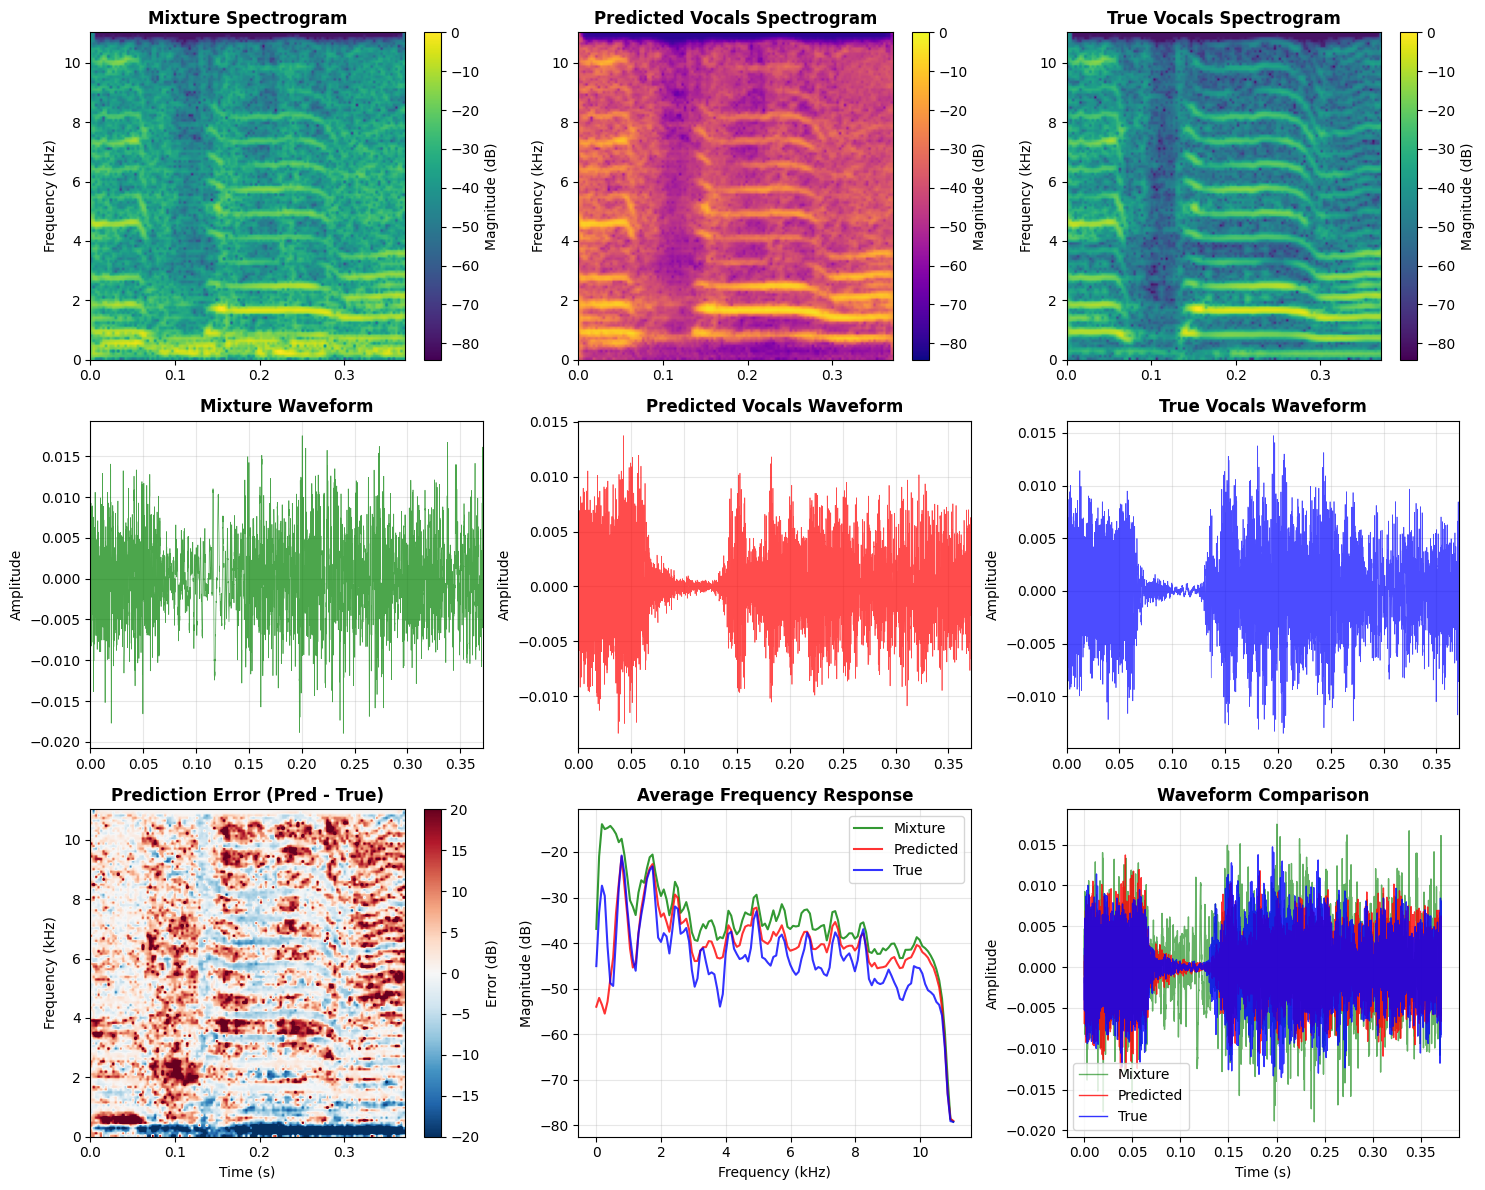


Audio reconstruction info:
Sample rate: 22050 Hz
Frame length: 8192 samples
Audio duration: 0.37 seconds
Waveform shapes:
Mixture: (8192,)
Predicted: (8192,)
True: (8192,)

Spectrogram value ranges (dB):
Mixture: -80.00 to 0.00
Predicted: -79.96 to -4.23
True: -80.00 to 0.00


TypeError: `x` and `y` must have the same dtype, got tf.float64 != tf.float32.

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

# Chọn một mẫu ngẫu nhiên từ test set
random_idx = random.randint(0, len(X_test) - 1)
print(f"Selected random sample index: {random_idx}")

# Lấy mixture và true vocals
mixture_spec = X_test[random_idx]  # Shape: (128, 128, 1)
true_vocals_spec = y_test[random_idx]  # Shape: (128, 128, 1)

# Predict vocals từ mixture
predicted_vocals_spec = generator_nn.predict(mixture_spec.reshape(1, 128, 128, 1))
predicted_vocals_spec = predicted_vocals_spec[0]  # Remove batch dimension

# Chuyển đổi từ normalized spectrogram về dB scale sử dụng hàm từ preprocessing
spec_mix = inv_scaled_in(mixture_spec[:,:,0])  # Shape: (128, 128)
spec_pred = inv_scaled_ou(predicted_vocals_spec[:,:,0])  # Shape: (128, 128)
spec_true = inv_scaled_ou(true_vocals_spec[:,:,0])  # Shape: (128, 128)

# Các tham số audio từ preprocessing code
sample_rate = 22050  # hoặc sample rate được sử dụng trong preprocessing
n_fft = 256  # để có 128 frequency bins (n_fft//2 + 1 = 129, cắt thành 128)
hop_length_fft = 64  # hop length cho STFT
frame_length = 8192  # frame length từ preprocessing
freq_limit = sample_rate // 2  # Nyquist frequency

# Tạo time và frequency axes
n_frames = spec_mix.shape[1]  # 128
n_freqs = spec_mix.shape[0]   # 128

t_mix = np.linspace(0, n_frames * hop_length_fft / sample_rate, n_frames)
t_pred = t_mix.copy()
t_true = t_mix.copy()

f_mix = np.linspace(0, freq_limit, n_freqs)
freq_idx = slice(0, n_freqs)  # Sử dụng tất cả frequency bins

# Tạo phase giả để reconstruct audio (vì chỉ có magnitude)
# Sử dụng random phase - thông thường trong audio processing
np.random.seed(42)  # For reproducible results
phase_mix = np.exp(1j * np.random.uniform(-np.pi, np.pi, spec_mix.shape))
phase_pred = np.exp(1j * np.random.uniform(-np.pi, np.pi, spec_pred.shape))
phase_true = np.exp(1j * np.random.uniform(-np.pi, np.pi, spec_true.shape))

# Reconstruct audio từ magnitude spectrogram và random phase
mixture = magnitude_db_and_phase_to_audio(frame_length, hop_length_fft, spec_mix, phase_mix)
vocals_pred = magnitude_db_and_phase_to_audio(frame_length, hop_length_fft, spec_pred, phase_pred)
vocals_true = magnitude_db_and_phase_to_audio(frame_length, hop_length_fft, spec_true, phase_true)

# Tạo figure với 9 subplots
plt.figure(figsize=(15, 12))

# Common colormap settings
vmin = min(spec_mix.max(), spec_pred.max(), spec_true.max()) - 80
vmax = max(spec_mix.max(), spec_pred.max(), spec_true.max())

# 1. Mixture spectrogram
plt.subplot(3, 3, 1)
im1 = plt.imshow(spec_mix[freq_idx], aspect='auto', origin='lower',
                extent=[t_mix[0], t_mix[-1], 0, freq_limit/1000],
                cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Mixture Spectrogram', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (kHz)')
plt.colorbar(im1, label='Magnitude (dB)')

# 2. Predicted vocals spectrogram  
plt.subplot(3, 3, 2)
im2 = plt.imshow(spec_pred[freq_idx], aspect='auto', origin='lower',
                extent=[t_pred[0], t_pred[-1], 0, freq_limit/1000],
                cmap='plasma', vmin=vmin, vmax=vmax)
plt.title('Predicted Vocals Spectrogram', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (kHz)')
plt.colorbar(im2, label='Magnitude (dB)')

# 3. True vocals spectrogram
plt.subplot(3, 3, 3)
im3 = plt.imshow(spec_true[freq_idx], aspect='auto', origin='lower',
                extent=[t_true[0], t_true[-1], 0, freq_limit/1000],
                cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('True Vocals Spectrogram', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (kHz)')
plt.colorbar(im3, label='Magnitude (dB)')

# 4-6. Waveforms - sử dụng audio thực được reconstruct từ spectrogram
time_mix = np.linspace(0, len(mixture)/sample_rate, len(mixture))
time_pred = np.linspace(0, len(vocals_pred)/sample_rate, len(vocals_pred))
time_true = np.linspace(0, len(vocals_true)/sample_rate, len(vocals_true))

plt.subplot(3, 3, 4)
plt.plot(time_mix, mixture, color='green', alpha=0.7, linewidth=0.5)
plt.title('Mixture Waveform', fontweight='bold')
plt.ylabel('Amplitude')
plt.xlim(0, time_mix[-1])
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 5)
plt.plot(time_pred, vocals_pred, color='red', alpha=0.7, linewidth=0.5)
plt.title('Predicted Vocals Waveform', fontweight='bold')
plt.ylabel('Amplitude')
plt.xlim(0, time_pred[-1])
plt.grid(True, alpha=0.3)

plt.subplot(3, 3, 6)
plt.plot(time_true, vocals_true, color='blue', alpha=0.7, linewidth=0.5)
plt.title('True Vocals Waveform', fontweight='bold')
plt.ylabel('Amplitude')
plt.xlim(0, time_true[-1])
plt.grid(True, alpha=0.3)

# 7. Difference spectrogram (Error visualization)
spec_diff = spec_pred - spec_true
plt.subplot(3, 3, 7)
im4 = plt.imshow(spec_diff[freq_idx], aspect='auto', origin='lower',
                extent=[t_pred[0], t_pred[-1], 0, freq_limit/1000],
                cmap='RdBu_r', vmin=-20, vmax=20)
plt.title('Prediction Error (Pred - True)', fontweight='bold')
plt.ylabel('Frequency (kHz)')
plt.xlabel('Time (s)')
plt.colorbar(im4, label='Error (dB)')

# 8. Frequency analysis comparison
plt.subplot(3, 3, 8)
avg_spec_mix = np.mean(spec_mix[freq_idx], axis=1)
avg_spec_pred = np.mean(spec_pred[freq_idx], axis=1) 
avg_spec_true = np.mean(spec_true[freq_idx], axis=1)
freq_khz = f_mix[freq_idx] / 1000

plt.plot(freq_khz, avg_spec_mix, label='Mixture', color='green', alpha=0.8)
plt.plot(freq_khz, avg_spec_pred, label='Predicted', color='red', alpha=0.8)
plt.plot(freq_khz, avg_spec_true, label='True', color='blue', alpha=0.8)
plt.title('Average Frequency Response', fontweight='bold')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Time-domain comparison - hiển thị waveform thực không normalize
plt.subplot(3, 3, 9)
# Hiển thị một phần của waveform để dễ nhìn (first quarter)
quarter_len = len(mixture)
quarter_mix = mixture[:quarter_len]
quarter_pred = vocals_pred[:quarter_len] if len(vocals_pred) >= quarter_len else vocals_pred
quarter_true = vocals_true[:quarter_len] if len(vocals_true) >= quarter_len else vocals_true

time_quarter_mix = time_mix[:len(quarter_mix)]
time_quarter_pred = time_pred[:len(quarter_pred)]
time_quarter_true = time_true[:len(quarter_true)]

plt.plot(time_quarter_mix, quarter_mix, 
         label='Mixture', color='green', alpha=0.6, linewidth=1)
plt.plot(time_quarter_pred, quarter_pred, 
         label='Predicted', color='red', alpha=0.8, linewidth=1)
plt.plot(time_quarter_true, quarter_true, 
         label='True', color='blue', alpha=0.8, linewidth=1)
plt.title('Waveform Comparison', fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In thông tin thêm
print(f"\nAudio reconstruction info:")
print(f"Sample rate: {sample_rate} Hz")
print(f"Frame length: {frame_length} samples")
print(f"Audio duration: {len(mixture)/sample_rate:.2f} seconds")
print(f"Waveform shapes:")
print(f"Mixture: {mixture.shape}")
print(f"Predicted: {vocals_pred.shape}")
print(f"True: {vocals_true.shape}")

print(f"\nSpectrogram value ranges (dB):")
print(f"Mixture: {spec_mix.min():.2f} to {spec_mix.max():.2f}")
print(f"Predicted: {spec_pred.min():.2f} to {spec_pred.max():.2f}")
print(f"True: {spec_true.min():.2f} to {spec_true.max():.2f}")

# Tính toán SDR metric
sdr_value = sdr(true_vocals_spec.reshape(1, 128, 128, 1), 
                predicted_vocals_spec.reshape(1, 128, 128, 1)).numpy()
print(f"\nSDR (Signal-to-Distortion Ratio): {sdr_value:.2f} dB")